In [ ]:
# 1. Imports and Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load the dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- Data Types ---")
print(df.dtypes, "\n")

print("--- Null Value Check ---")
print(df.isnull().sum(), "\n")

print("--- Descriptive Statistics ---")
display(df.describe())

--- Dataset Shape ---
Rows: 150, Columns: 5

--- Data Types ---
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object 

--- Null Value Check ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64 

--- Descriptive Statistics ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


--- Pairplot: Feature Distributions by Species ---


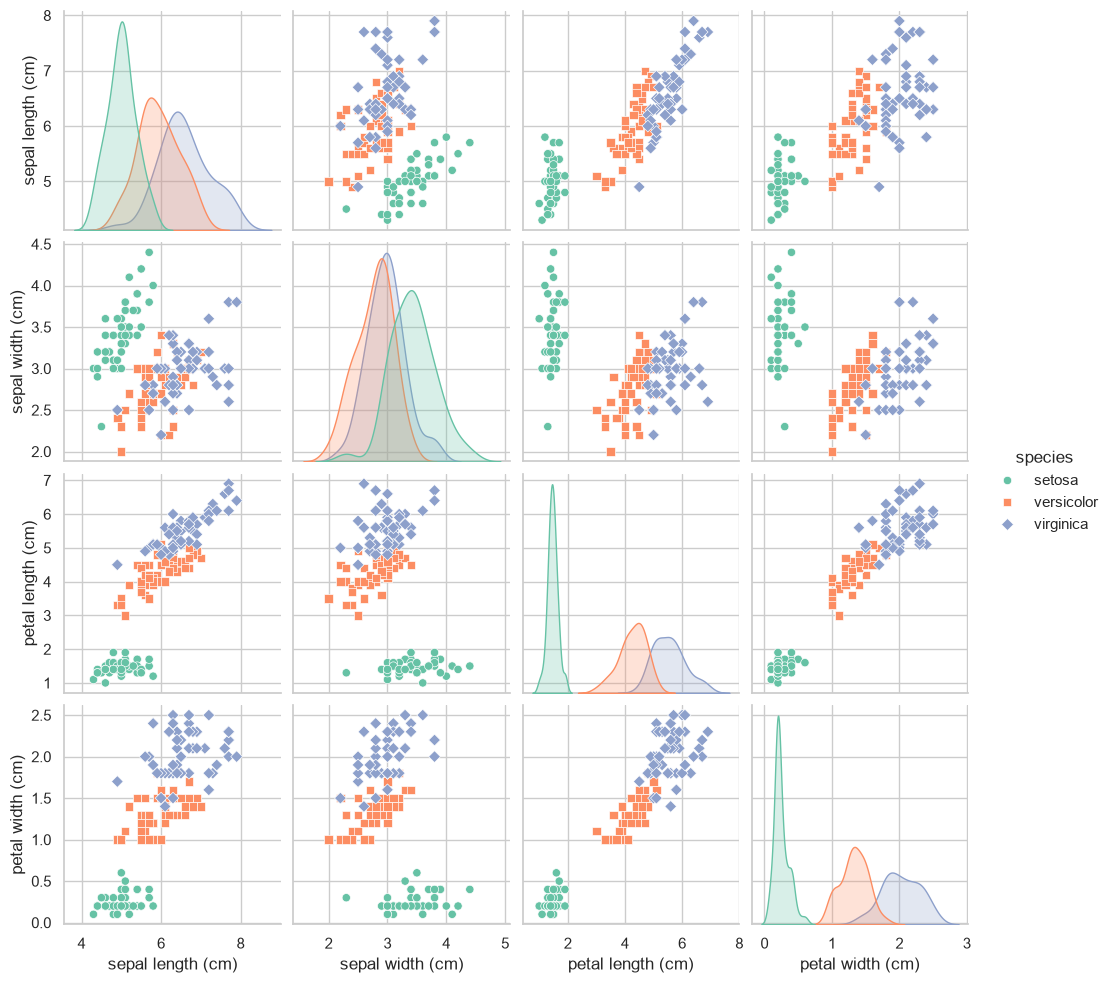


--- Box Plots: Feature Spread by Species ---


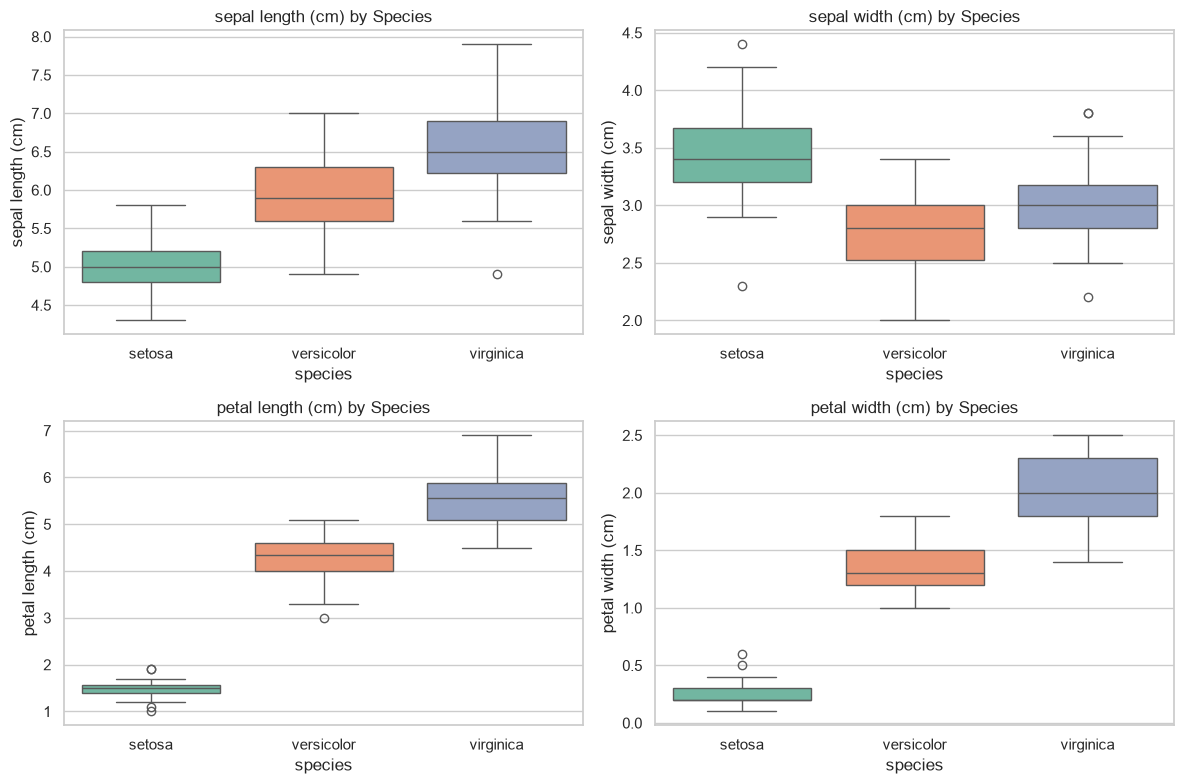

In [ ]:
# 3. Visualizations

sns.set_theme(style="whitegrid")

# Pairplot
print("Pairplot: Feature Distributions by Species :")
sns.pairplot(df, hue="species", markers=["o", "s", "D"], palette="Set2")
plt.show()

print("\nBox Plots: Feature Spread by Species :")
plt.figure(figsize=(12, 8))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    # The updated boxplot code goes here inside the loop:
    sns.boxplot(x="species", y=feature, data=df, hue="species", palette="Set2", legend=False)
    plt.title(f"{feature} by Species")
    
plt.tight_layout()
plt.show()

### 4. Feature Selection Discussion
Based on the pairplot and box plots above, the most discriminative features are **petal length (cm)** and **petal width (cm)**. 
* **Setosa** is completely linearly separable from the other two species using just these petal measurements.
* **Versicolor** and **Virginica** have a slight overlap, but petal dimensions still provide the clearest boundary between them compared to sepal length and sepal width, which show heavy overlapping across all species.
Therefore, petal measurements will carry the most weight in training an accurate classification model.

In [ ]:
# 5. Train/Test Split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('species', axis=1)
y = df['species']

# Hide 20% of the flowers for the final exam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Logistic Regression 
print("=== MODEL 1: LOGISTIC REGRESSION ===")
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train) # This generates the logic
lr_predictions = lr_model.predict(X_test) # This takes the exam

print(f"Accuracy: {accuracy_score(y_test, lr_predictions):.4f}")
print("Classification Report:\n", classification_report(y_test, lr_predictions))

# Model 2: Random Forest
print("\n=== MODEL 2: RANDOM FOREST ===")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train) # This generates the logic
rf_predictions = rf_model.predict(X_test) # This takes the exam

print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print("Classification Report:\n", classification_report(y_test, rf_predictions))

=== MODEL 1: LOGISTIC REGRESSION ===
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


=== MODEL 2: RANDOM FOREST ===
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### 6. Best Performing Model Declaration
Both **Logistic egression** and **Random Forest** achieved an accuracy of 100% on the test set. Because the Iris dataset features clear geometric boundaries, both algorithms easily mapped the classes. 

However, **Logistic Regression** is declared the best-performing model for this specific task. Since the dataset is small (150 rows), Logistic Regression is computationally faster, simpler, and less prone to overfitting than a complex ensemble method like Random Forest.